In [24]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import shap
import matplotlib.pyplot as plt

from src.utils.model_io import load_model
from src.features.engineering import engineer_features
from src.features.preprocessing import get_feature_types

In [25]:
model_path = Path(
    "../models/spaceship_titanic_catboost.joblib"
)

pipeline = load_model(model_path)

preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]

train_df = pd.read_csv("../data/raw/train.csv")
X = train_df.drop(columns="Transported")

X = engineer_features(X)
X = X.drop(columns=["PassengerId", "Name", "Cabin"])

X_transformed = preprocessor.transform(X)
X_transformed.shape

(8693, 32)

In [26]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__Age', 'num__RoomService', 'num__FoodCourt',
       'num__ShoppingMall', 'num__Spa', 'num__VRDeck', 'num__TotalSpend',
       'num__GroupSize', 'cat__HomePlanet_Earth',
       'cat__HomePlanet_Europa', 'cat__HomePlanet_Mars',
       'cat__CryoSleep_False', 'cat__CryoSleep_True',
       'cat__Destination_55 Cancri e', 'cat__Destination_PSO J318.5-22',
       'cat__Destination_TRAPPIST-1e', 'cat__VIP_False', 'cat__VIP_True',
       'cat__HasSpentMoney_False', 'cat__HasSpentMoney_True',
       'cat__IsAlone_False', 'cat__IsAlone_True', 'cat__Deck_A',
       'cat__Deck_B', 'cat__Deck_C', 'cat__Deck_D', 'cat__Deck_E',
       'cat__Deck_F', 'cat__Deck_G', 'cat__Deck_T', 'cat__CabinSide_P',
       'cat__CabinSide_S'], dtype=object)

In [27]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_transformed)
shap_values.shape

(8693, 32)

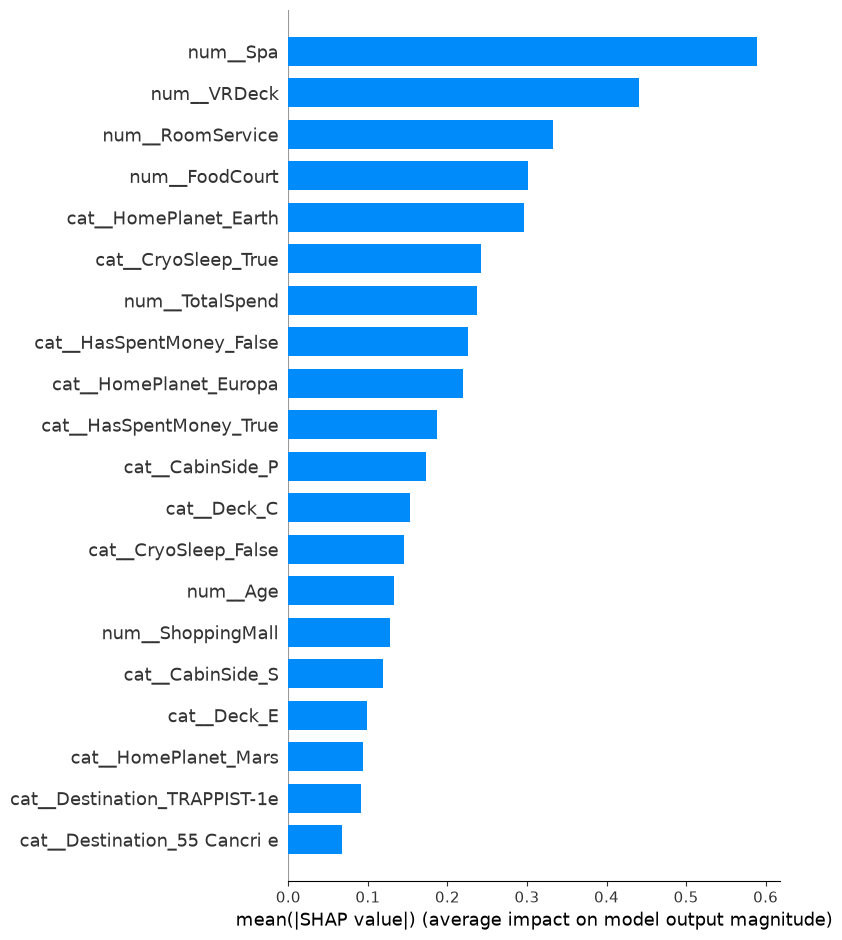

In [28]:
X_sample = X_transformed[:500]
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
)

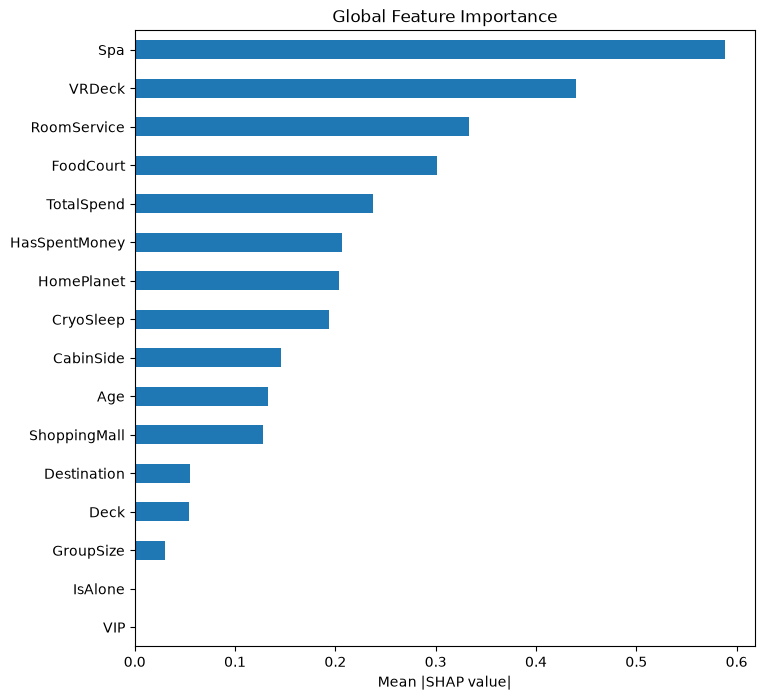

In [29]:
import numpy as np

numeric_features, categorical_features = get_feature_types(X)

cat_encoder = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

cat_feature_names = cat_encoder.get_feature_names_out(
    categorical_features
)

feature_groups = {}

for feature in numeric_features:
    feature_groups[feature] = [
        f"num__{feature}"
    ]

for feature in categorical_features:
    feature_groups[feature] = [
        name
        for name in feature_names
        if name.startswith(f"cat__{feature}_")
    ]

feature_index = {
    name: i
    for i, name in enumerate(feature_names)
}

grouped_importance = {}

for feature, transformed_features in feature_groups.items():
    indices = [
        feature_index[name]
        for name in transformed_features
    ]

    grouped_importance[feature] = np.abs(
        shap_values[:, indices]
    ).mean()

grouped_importance = (
    pd.Series(grouped_importance)
    .sort_values(ascending=False)
)

grouped_importance.head(20)

grouped_importance.head(20).sort_values().plot(
    kind="barh",
    figsize=(8, 8),
)

plt.xlabel("Mean |SHAP value|")
plt.title("Global Feature Importance")
plt.show()

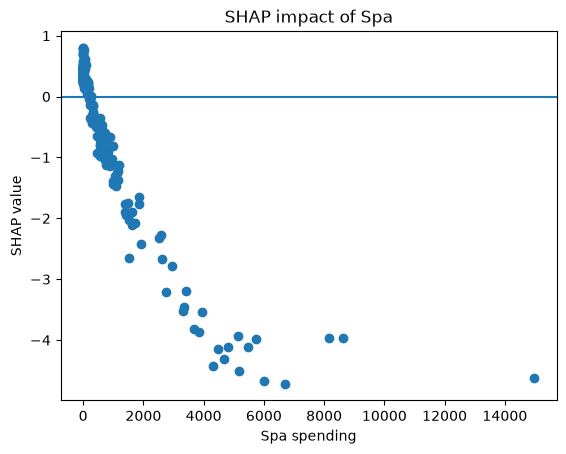

In [30]:
spa_index = feature_index["num__Spa"]
spa_shap = shap_values[:, spa_index]

X_sample_original = X.iloc[:500]
spa_values = X_sample_original["Spa"].values

plt.scatter(
    spa_values,
    spa_shap,
)

plt.axhline(0)
plt.xlabel("Spa spending")
plt.ylabel("SHAP value")
plt.title("SHAP impact of Spa")
plt.show()

SHAP analysis shows that Spa spending has a strong and non-linear influence on the model's predictions. Low or zero spending generally has a limited impact, while very high Spa spending produces increasingly strong contributions in the opposite direction.

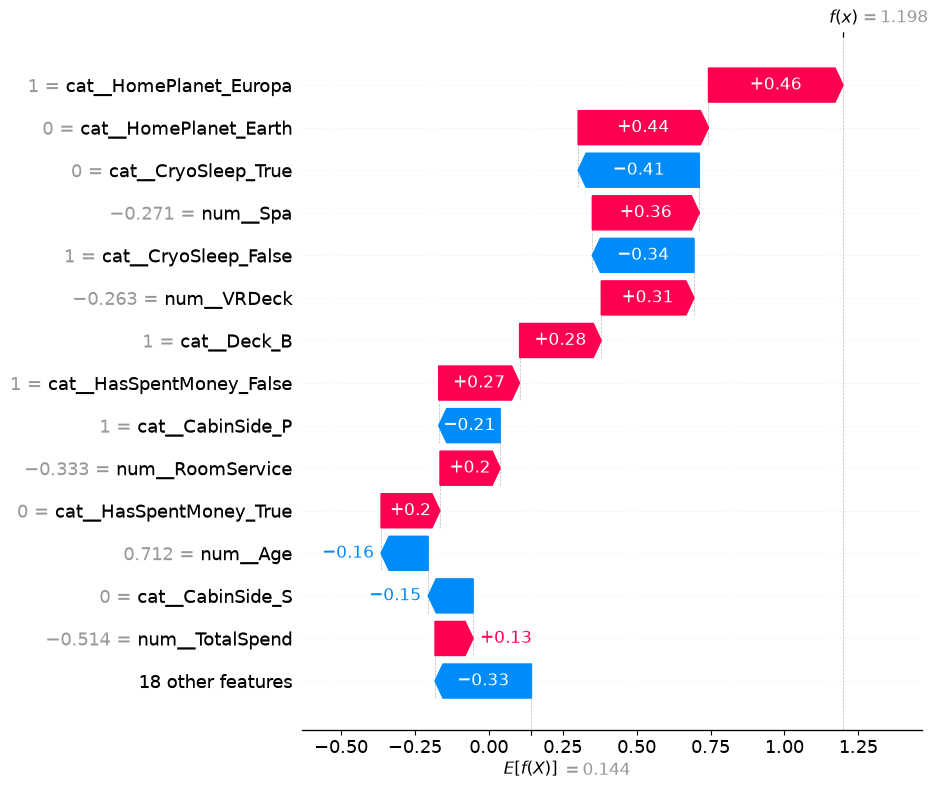

In [32]:
X_single = X_sample[0].flatten()
shap_single = shap_values[0]

explanation = shap.Explanation(
    values=shap_single,
    base_values=explainer.expected_value,
    data=X_single,
    feature_names=feature_names,
)

shap.plots.waterfall(
    explanation,
    max_display=15,
)

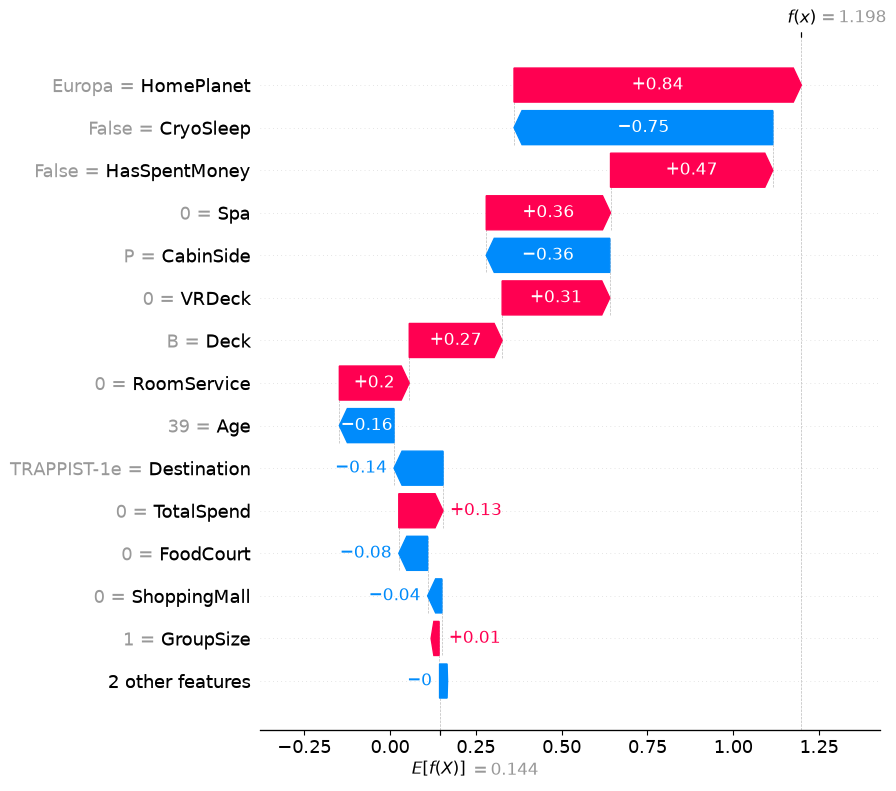

In [33]:
grouped_shap = {}
grouped_data = {}

for feature, transformed_features in feature_groups.items():
    indices = [
        feature_index[name]
        for name in transformed_features
    ]

    # Sumem els SHAP de totes les columnes
    # que provenen de la mateixa variable original
    grouped_shap[feature] = shap_single[indices].sum()

    # Valor original de la feature
    grouped_data[feature] = X.iloc[0][feature]

grouped_explanation = shap.Explanation(
    values=np.array([
        grouped_shap[feature]
        for feature in grouped_shap
    ]),
    base_values=explainer.expected_value,
    data=np.array([
        grouped_data[feature]
        for feature in grouped_data
    ], dtype=object),
    feature_names=list(grouped_shap.keys()),
)

shap.plots.waterfall(
    grouped_explanation,
    max_display=15,
)